# 🫀 CVD Detection — Full Pipeline

> **Groups:** Setup → Data Loading → EDA → Preprocessing → Resampling (SMOTE-ENN & SMOTE-Tomek) → Model Training & Tuning → Comparison


## GROUP 1 — Environment Setup


In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# Viz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
PALETTE = ["#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"]

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek, SMOTEENN

from scipy.stats.mstats import winsorize
import joblib
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment ready.")

✅ Environment ready.


## GROUP 2 — Data Loading & First Look


In [37]:
# ──────────────────────────────────────────────────────────────
# GROUP 2 — Data Loading & First Look
# ──────────────────────────────────────────────────────────────

# Adjust path to YOUR location
DATA_PATH = Path(r"G:\ML\DIgital Health Project\output\gha2006_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:\n", df.dtypes)

print("\nTarget distribution:")
print(df["Target (Raised BP)"].value_counts(normalize=True).round(4) * 100)

print("\nMissing %:")
print((df.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (2181, 17)

Columns:
['PID', 'sex', 'age', 'Smoking status', 'Alcohol intake', 'Physical activity', 'Sedentary Behaviour (Avg daily hours)', 'Diabetes status', 'BMI', 'Systolic BP', 'Diastolic BP', 'Heartrate', 'Blood Glucose', 'Total Cholesterol', 'Triglycerides', 'HDL Cholesterol', 'Target (Raised BP)']

Data types:
 PID                                        int64
sex                                       object
age                                        int64
Smoking status                             int64
Alcohol intake                           float64
Physical activity                        float64
Sedentary Behaviour (Avg daily hours)    float64
Diabetes status                          float64
BMI                                      float64
Systolic BP                              float64
Diastolic BP                             float64
Heartrate                                float64
Blood Glucose                            float64
Total Cholesterol                  

## GROUP 3 — Exploratory Data Analysis


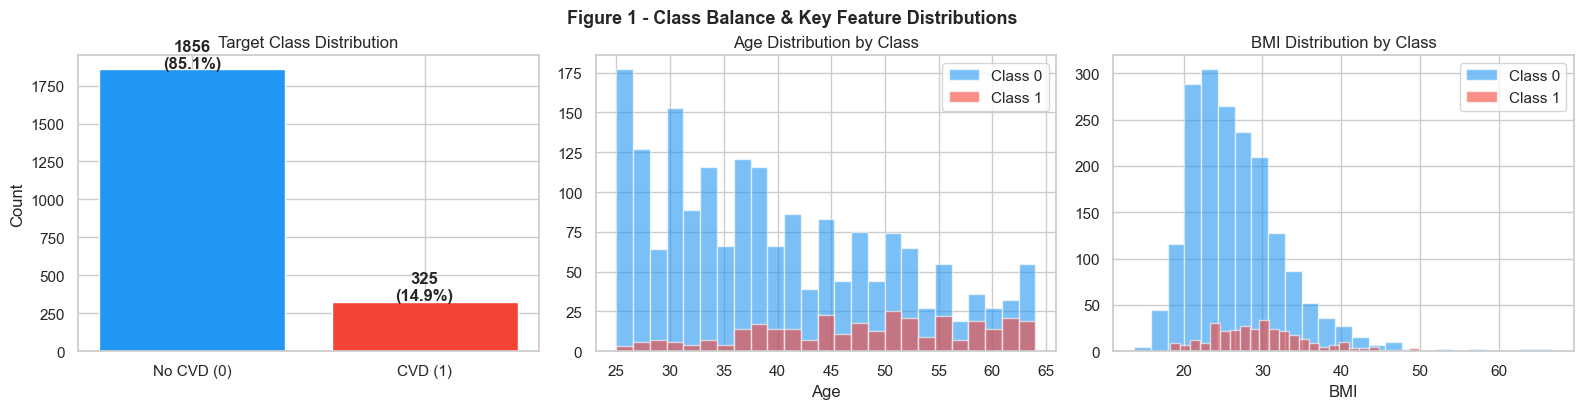

Saved fig1_eda_overview.png


In [40]:
# ── 3a. Class balance bar ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

target_counts = df["Target (Raised BP)"].value_counts()
axes[0].bar(["No CVD (0)", "CVD (1)"], target_counts.values,
            color=[PALETTE[0], PALETTE[1]], edgecolor="white")
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v) + "\n(" + str(round(v/len(df)*100,1)) + "%)",
                 ha="center", fontweight="bold")

# ── 3b. Age distribution by class ──
for cls, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    axes[1].hist(df[df["Target (Raised BP)"] == cls]["age"],
                 bins=25, alpha=0.6, label="Class " + str(cls), color=color, edgecolor="white")
axes[1].set_title("Age Distribution by Class")
axes[1].set_xlabel("Age")
axes[1].legend()

# ── 3c. BMI distribution by class ──
for cls, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
    axes[2].hist(df[df["Target (Raised BP)"] == cls]["BMI"].dropna(),
                 bins=25, alpha=0.6, label="Class " + str(cls), color=color, edgecolor="white")
axes[2].set_title("BMI Distribution by Class")
axes[2].set_xlabel("BMI")
axes[2].legend()

plt.tight_layout()
plt.suptitle("Figure 1 - Class Balance & Key Feature Distributions", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("fig1_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_eda_overview.png")


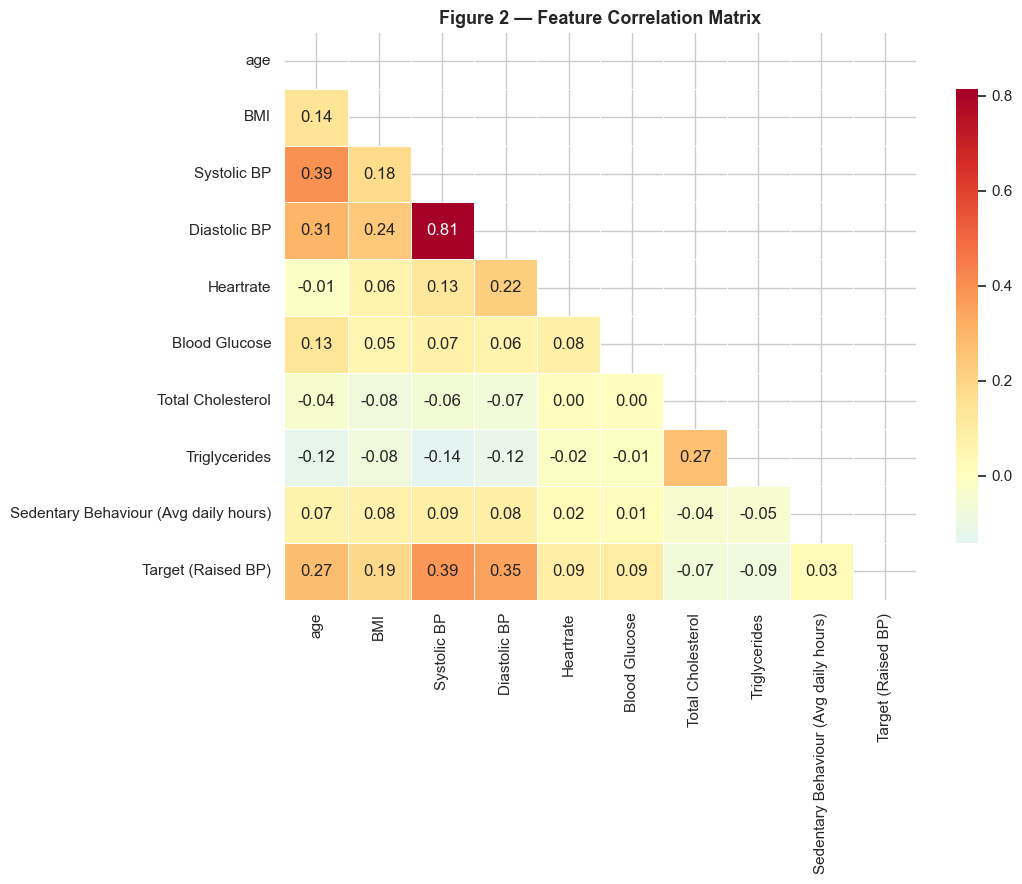

In [ ]:
# ── 3d. Correlation heatmap (numeric features) ──
num_cols = [
    "age",
    "BMI",
    "Systolic BP",
    "Diastolic BP",
    "Heartrate",
    "Blood Glucose",
    "Total Cholesterol",
    "Triglycerides",
    "Sedentary Behaviour (Avg daily hours)",
    "Target (Raised BP)",
]

existing = [c for c in num_cols if c in df.columns]
corr = df[existing].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Figure 2 — Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## GROUP 4 — Preprocessing & Train/Val/Test Split


In [ ]:
# ── 4a. Clean & type corrections ──
df_clean = df.copy()

# Drop 100% missing
if "HDL Cholesterol" in df_clean.columns:
    df_clean.drop(columns=["HDL Cholesterol"], inplace=True)
    print("Dropped: HDL Cholesterol (100% missing)")

# Rename columns
df_clean.columns = df_clean.columns.str.replace(
    r"[\s\(\)%/]+", "_", regex=True
).str.strip("_")

# Cast target
df_clean["Target_Raised_BP"] = df_clean["Target_Raised_BP"].round(0).astype(int)

TARGET = "Target_Raised_BP"
DROP_COLS = ["PID"]

CAT_FEATURES = [
    "sex",
    "Smoking_status",
    "Alcohol_intake",
    "Physical_activity",
    "Diabetes_status",
]

NUM_FEATURES = [
    "age",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP",
    "Heartrate",
    "Blood_Glucose",
    "Total_Cholesterol",
    "Triglycerides",
    "Sedentary_Behaviour_Avg_daily_hours",
]

dist = df_clean[TARGET].value_counts(normalize=True).mul(100).round(2)
print("Target distribution:")
print(dist)
print("Shape:", df_clean.shape)

Dropped: HDL Cholesterol (100% missing)
Target distribution:
Target_Raised_BP
0   85.1000
1   14.9000
Name: proportion, dtype: float64
Shape: (2181, 16)


In [ ]:
# ── 4b. Winsorize numeric features (1%-99%) ──
df_prep = df_clean.copy()

for col in NUM_FEATURES:
    if col in df_prep.columns:
        mask = df_prep[col].notna()
        vals = df_prep.loc[mask, col].values
        df_prep.loc[mask, col] = winsorize(vals, limits=[0.01, 0.01])
        print("  Winsorized " + col + ": " + str(mask.sum()) + " valid values")

print("")
print("Winsorization complete -- no rows dropped.")

  Winsorized age: 2181 valid values
  Winsorized BMI: 2168 valid values
  Winsorized Systolic_BP: 2175 valid values
  Winsorized Diastolic_BP: 2175 valid values
  Winsorized Heartrate: 2175 valid values
  Winsorized Blood_Glucose: 2174 valid values
  Winsorized Total_Cholesterol: 2167 valid values
  Winsorized Triglycerides: 2168 valid values
  Winsorized Sedentary_Behaviour_Avg_daily_hours: 2163 valid values

Winsorization complete -- no rows dropped.


In [ ]:
# ── 4c. Stratified train / val / test split ──
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

X = df_prep[ALL_FEATURES]
y = df_prep[TARGET]

# 70 / 15 / 15
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # 0.1765 * 0.85 ≈ 0.15
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

print(f"Train : {X_train.shape[0]:>5} samples  | positive: {y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape[0]:>5} samples  | positive: {y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:>5} samples  | positive: {y_test.mean()*100:.1f}%")

Train :  1525 samples  | positive: 14.9%
Val   :   328 samples  | positive: 14.9%
Test  :   328 samples  | positive: 14.9%


In [ ]:
# ── 4d. Build sklearn preprocessing transformer ──
numeric_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
        ("cat", categorical_transformer, CAT_FEATURES),
    ]
)

print("✅ Preprocessor defined.")

✅ Preprocessor defined.


## GROUP 5 — Model Definitions & Hyperparameter Grids


In [ ]:
# ── Base classifiers ──
base_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    ),
    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(),  # no class_weight; handled via resampling
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
}

# ── Hyperparameter grids (prefixed for ImbPipeline step name = "classifier") ──
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__penalty": ["l2"],
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto"],
    },
    "KNN": {
        "classifier__n_neighbors": [5, 9, 15, 21],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"],
    },
    "Random Forest": {
        "classifier__n_estimators": [150, 250],
        "classifier__max_depth": [8, 12, None],
        "classifier__min_samples_leaf": [2, 4],
        "classifier__class_weight": ["balanced", "balanced_subsample"],
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__scale_pos_weight": [
            (y_train == 0).sum() / (y_train == 1).sum()  # handles imbalance
        ],
    },
}

CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = "roc_auc"

print("✅ Models and grids defined.")
for name, grid in param_grids.items():
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f"  {name:25s}: {n_combos} combinations × 5 folds")

✅ Models and grids defined.
  Logistic Regression      : 4 combinations × 5 folds
  SVM                      : 6 combinations × 5 folds
  KNN                      : 16 combinations × 5 folds
  Random Forest            : 24 combinations × 5 folds
  XGBoost                  : 24 combinations × 5 folds


## GROUP 6 — Training & Evaluation Helpers


In [ ]:
def build_imb_pipeline(resampler, classifier):
    """Build an ImbPipeline: preprocessor -> resampler -> classifier."""
    return ImbPipeline(
        [
            ("preprocessor", preprocessor),
            ("resampler", resampler),
            ("classifier", classifier),
        ]
    )


def evaluate_pipeline(pipeline, X_eval, y_eval, model_name, strategy_name):
    """Return a dict of evaluation metrics."""
    y_prob = pipeline.predict_proba(X_eval)[:, 1]
    y_pred = pipeline.predict(X_eval)
    return {
        "Model": model_name,
        "Strategy": strategy_name,
        "ROC-AUC": round(roc_auc_score(y_eval, y_prob), 4),
        "AP": round(average_precision_score(y_eval, y_prob), 4),
        "Recall-1": round(recall_score(y_eval, y_pred, zero_division=0), 4),
        "Precision-1": round(precision_score(y_eval, y_pred, zero_division=0), 4),
        "F1-1": round(f1_score(y_eval, y_pred, zero_division=0), 4),
        "Accuracy": round((y_pred == y_eval).mean(), 4),
        "_y_prob": y_prob,
        "_y_pred": y_pred,
    }


def train_all_models(resampler_fn, strategy_name, X_tr, y_tr, X_v, y_v):
    """
    Loop over all base models, run GridSearchCV, return metrics DataFrame.
    resampler_fn: callable that returns a fresh resampler instance.
    """
    results = []
    best_pipelines = {}

    for model_name, base_clf in base_models.items():
        print("  [" + strategy_name + "] Training " + model_name + " ...")

        pipe = build_imb_pipeline(resampler_fn(), base_clf)

        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[model_name],
            cv=CV_STRATEGY,
            scoring=SCORING,
            n_jobs=-1,
            verbose=0,
            refit=True,
        )
        grid_search.fit(X_tr, y_tr)

        best_pipe = grid_search.best_estimator_
        best_pipelines[model_name] = best_pipe

        val_metrics = evaluate_pipeline(best_pipe, X_v, y_v, model_name, strategy_name)
        val_metrics["Best Params"] = str(grid_search.best_params_)
        val_metrics["CV ROC-AUC"] = round(grid_search.best_score_, 4)
        results.append(val_metrics)

        print(
            "    CV AUC: "
            + str(grid_search.best_score_.__round__(4))
            + "  |  Val AUC: "
            + str(val_metrics["ROC-AUC"])
            + "  |  Recall-1: "
            + str(val_metrics["Recall-1"])
        )

    return pd.DataFrame(results), best_pipelines


print("Helper functions defined.")

Helper functions defined.


## GROUP 7 — Training with SMOTE-ENN


In [ ]:
print("=" * 60)
print("SMOTE-ENN Training Run")
print("=" * 60)

smoteenn_results, smoteenn_pipelines = train_all_models(
    resampler_fn=lambda: SMOTEENN(random_state=RANDOM_STATE),
    strategy_name="SMOTE-ENN",
    X_tr=X_train,
    y_tr=y_train,
    X_v=X_val,
    y_v=y_val,
)

print("")
print("SMOTE-ENN training complete.")
cols = ["Model", "Strategy", "CV ROC-AUC", "ROC-AUC", "Recall-1", "Precision-1", "F1-1"]
print(smoteenn_results[cols].to_string(index=False))

SMOTE-ENN Training Run
  [SMOTE-ENN] Training Logistic Regression ...
    CV AUC: 0.8288  |  Val AUC: 0.8551  |  Recall-1: 0.8163
  [SMOTE-ENN] Training SVM ...
    CV AUC: 0.8173  |  Val AUC: 0.8443  |  Recall-1: 0.7959
  [SMOTE-ENN] Training KNN ...
    CV AUC: 0.8075  |  Val AUC: 0.7912  |  Recall-1: 0.8163
  [SMOTE-ENN] Training Random Forest ...
    CV AUC: 0.8184  |  Val AUC: 0.8275  |  Recall-1: 0.7347
  [SMOTE-ENN] Training XGBoost ...
    CV AUC: 0.8164  |  Val AUC: 0.8146  |  Recall-1: 0.7551

SMOTE-ENN training complete.
              Model  Strategy  CV ROC-AUC  ROC-AUC  Recall-1  Precision-1   F1-1
Logistic Regression SMOTE-ENN      0.8288   0.8551    0.8163       0.3333 0.4734
                SVM SMOTE-ENN      0.8173   0.8443    0.7959       0.3250 0.4615
                KNN SMOTE-ENN      0.8075   0.7912    0.8163       0.2857 0.4233
      Random Forest SMOTE-ENN      0.8184   0.8275    0.7347       0.3600 0.4832
            XGBoost SMOTE-ENN      0.8164   0.8146    0.7

## GROUP 8 — Training with SMOTE-Tomek


In [ ]:
print("=" * 60)
print("SMOTE-Tomek Links Training Run")
print("=" * 60)

smotetomek_results, smotetomek_pipelines = train_all_models(
    resampler_fn=lambda: SMOTETomek(random_state=RANDOM_STATE),
    strategy_name="SMOTE-Tomek",
    X_tr=X_train,
    y_tr=y_train,
    X_v=X_val,
    y_v=y_val,
)

print("")
print("SMOTE-Tomek training complete.")
cols = ["Model", "Strategy", "CV ROC-AUC", "ROC-AUC", "Recall-1", "Precision-1", "F1-1"]
print(smotetomek_results[cols].to_string(index=False))

SMOTE-Tomek Links Training Run
  [SMOTE-Tomek] Training Logistic Regression ...
    CV AUC: 0.8305  |  Val AUC: 0.8484  |  Recall-1: 0.7551
  [SMOTE-Tomek] Training SVM ...
    CV AUC: 0.822  |  Val AUC: 0.8397  |  Recall-1: 0.7347
  [SMOTE-Tomek] Training KNN ...
    CV AUC: 0.79  |  Val AUC: 0.7844  |  Recall-1: 0.6735
  [SMOTE-Tomek] Training Random Forest ...
    CV AUC: 0.8145  |  Val AUC: 0.8107  |  Recall-1: 0.5102
  [SMOTE-Tomek] Training XGBoost ...
    CV AUC: 0.8055  |  Val AUC: 0.7885  |  Recall-1: 0.8571

SMOTE-Tomek training complete.
              Model    Strategy  CV ROC-AUC  ROC-AUC  Recall-1  Precision-1   F1-1
Logistic Regression SMOTE-Tomek      0.8305   0.8484    0.7551       0.3737 0.5000
                SVM SMOTE-Tomek      0.8220   0.8397    0.7347       0.3673 0.4898
                KNN SMOTE-Tomek      0.7900   0.7844    0.6735       0.3143 0.4286
      Random Forest SMOTE-Tomek      0.8145   0.8107    0.5102       0.4464 0.4762
            XGBoost SMOTE-Tome

## GROUP 9 — Combined Results & Comparison Tables


In [ ]:
# ── 9a. Combine all results ──
all_results = pd.concat([smoteenn_results, smotetomek_results], ignore_index=True)

# Drop internal columns before display
display_cols = [
    "Model",
    "Strategy",
    "CV ROC-AUC",
    "ROC-AUC",
    "AP",
    "Recall-1",
    "Precision-1",
    "F1-1",
    "Accuracy",
]
summary = all_results[display_cols].sort_values(
    ["ROC-AUC", "Recall-1"], ascending=False
)

print("=" * 90)
print(" FULL COMPARISON TABLE (sorted by ROC-AUC)")
print("=" * 90)
print(summary.to_string(index=False))

 FULL COMPARISON TABLE (sorted by ROC-AUC)
              Model    Strategy  CV ROC-AUC  ROC-AUC     AP  Recall-1  Precision-1   F1-1  Accuracy
Logistic Regression   SMOTE-ENN      0.8288   0.8551 0.5101    0.8163       0.3333 0.4734    0.7287
Logistic Regression SMOTE-Tomek      0.8305   0.8484 0.4949    0.7551       0.3737 0.5000    0.7744
                SVM   SMOTE-ENN      0.8173   0.8443 0.4914    0.7959       0.3250 0.4615    0.7226
                SVM SMOTE-Tomek      0.8220   0.8397 0.4843    0.7347       0.3673 0.4898    0.7713
      Random Forest   SMOTE-ENN      0.8184   0.8275 0.4742    0.7347       0.3600 0.4832    0.7652
            XGBoost   SMOTE-ENN      0.8164   0.8146 0.4216    0.7551       0.3426 0.4713    0.7470
      Random Forest SMOTE-Tomek      0.8145   0.8107 0.4455    0.5102       0.4464 0.4762    0.8323
                KNN   SMOTE-ENN      0.8075   0.7912 0.4031    0.8163       0.2857 0.4233    0.6677
            XGBoost SMOTE-Tomek      0.8055   0.7885 0.43

In [ ]:
# ── 9b. Side-by-side pivot: ROC-AUC, Recall, F1 ──
for metric in ["ROC-AUC", "Recall-1", "F1-1"]:
    pivot = all_results.pivot(index="Model", columns="Strategy", values=metric)
    pivot["Delta (Tomek - ENN)"] = pivot["SMOTE-Tomek"] - pivot["SMOTE-ENN"]
    print("")
    print("-" * 55)
    print("  " + metric)
    print("-" * 55)
    print(pivot.round(4).to_string())


-------------------------------------------------------
  ROC-AUC
-------------------------------------------------------
Strategy             SMOTE-ENN  SMOTE-Tomek  Delta (Tomek - ENN)
Model                                                           
KNN                     0.7912       0.7844              -0.0068
Logistic Regression     0.8551       0.8484              -0.0067
Random Forest           0.8275       0.8107              -0.0168
SVM                     0.8443       0.8397              -0.0046
XGBoost                 0.8146       0.7885              -0.0261

-------------------------------------------------------
  Recall-1
-------------------------------------------------------
Strategy             SMOTE-ENN  SMOTE-Tomek  Delta (Tomek - ENN)
Model                                                           
KNN                     0.8163       0.6735              -0.1428
Logistic Regression     0.8163       0.7551              -0.0612
Random Forest           0.7347       0

In [ ]:
# ── 9c. Best models per strategy ──
print("")
print("Best model per strategy (by ROC-AUC):")
for strategy in ["SMOTE-ENN", "SMOTE-Tomek"]:
    row = (
        all_results[all_results["Strategy"] == strategy]
        .sort_values("ROC-AUC", ascending=False)
        .iloc[0]
    )
    print(
        "  "
        + strategy
        + ": "
        + row["Model"]
        + "  | AUC="
        + str(row["ROC-AUC"])
        + "  Recall="
        + str(row["Recall-1"])
        + "  F1="
        + str(row["F1-1"])
    )

print("")
print("Best model per strategy (by Recall -- most important for CVD screening):")
for strategy in ["SMOTE-ENN", "SMOTE-Tomek"]:
    row = (
        all_results[all_results["Strategy"] == strategy]
        .sort_values(["Recall-1", "ROC-AUC"], ascending=False)
        .iloc[0]
    )
    print(
        "  "
        + strategy
        + ": "
        + row["Model"]
        + "  | AUC="
        + str(row["ROC-AUC"])
        + "  Recall="
        + str(row["Recall-1"])
        + "  F1="
        + str(row["F1-1"])
    )


Best model per strategy (by ROC-AUC):
  SMOTE-ENN: Logistic Regression  | AUC=0.8551  Recall=0.8163  F1=0.4734
  SMOTE-Tomek: Logistic Regression  | AUC=0.8484  Recall=0.7551  F1=0.5

Best model per strategy (by Recall -- most important for CVD screening):
  SMOTE-ENN: Logistic Regression  | AUC=0.8551  Recall=0.8163  F1=0.4734
  SMOTE-Tomek: XGBoost  | AUC=0.7885  Recall=0.8571  F1=0.4038


## GROUP 10 — Comparison Visualisations


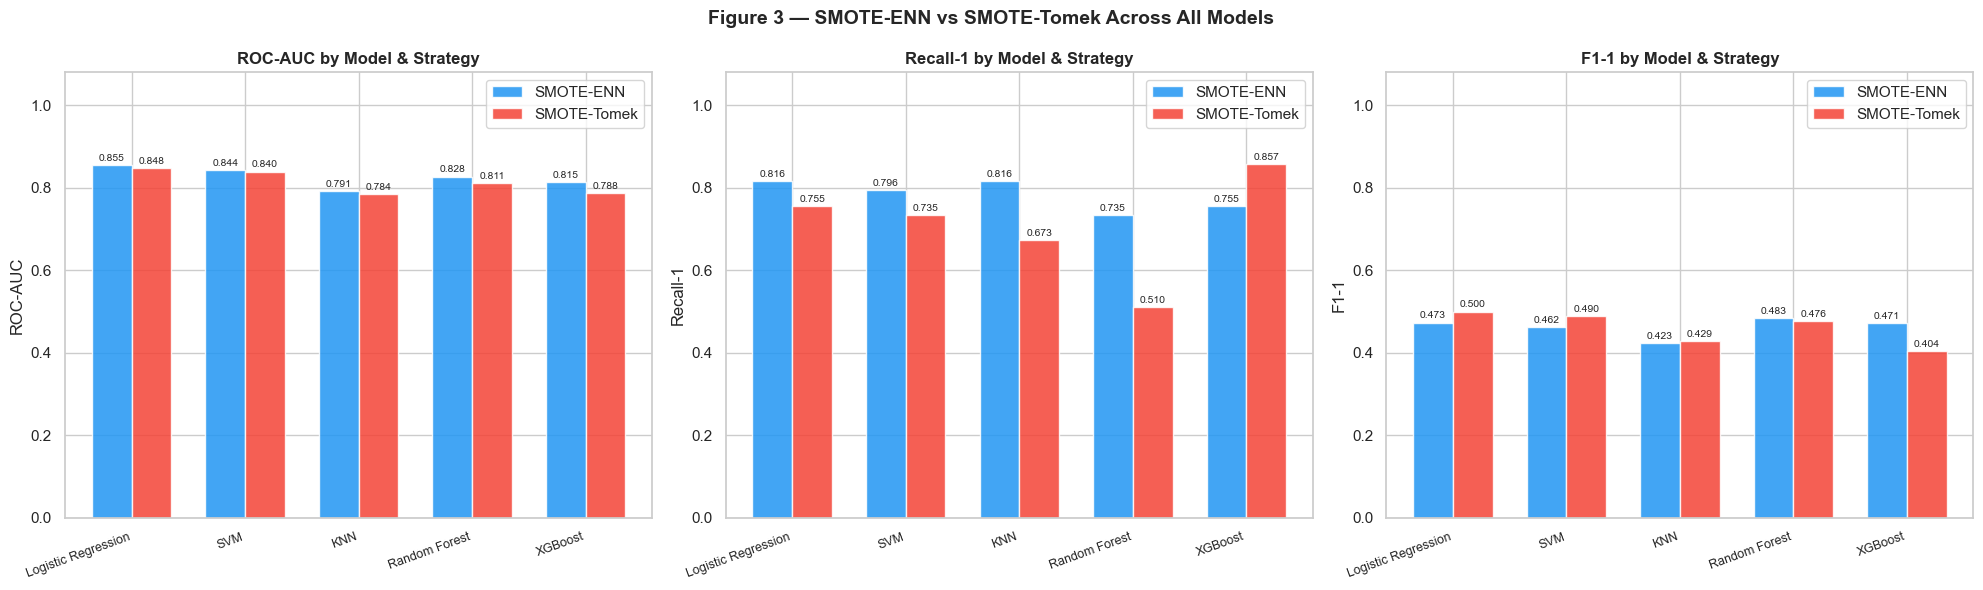

Saved fig3_comparison_bars.png


In [ ]:
# ── 10a. Grouped bar chart — ROC-AUC, Recall, F1 by model & strategy ──
metrics_to_plot = ["ROC-AUC", "Recall-1", "F1-1"]
strategies = ["SMOTE-ENN", "SMOTE-Tomek"]
model_names = list(base_models.keys())
x = np.arange(len(model_names))
width = 0.35
colors = {"SMOTE-ENN": PALETTE[0], "SMOTE-Tomek": PALETTE[1]}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric in zip(axes, metrics_to_plot):
    for i, strategy in enumerate(strategies):
        vals = [
            all_results[
                (all_results["Model"] == m) & (all_results["Strategy"] == strategy)
            ][metric].values[0]
            for m in model_names
        ]
        bars = ax.bar(
            x + (i - 0.5) * width,
            vals,
            width,
            label=strategy,
            color=colors[strategy],
            alpha=0.85,
            edgecolor="white",
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
            )
    ax.set_title(f"{metric} by Model & Strategy", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.legend()
    ax.set_ylabel(metric)

plt.suptitle(
    "Figure 3 — SMOTE-ENN vs SMOTE-Tomek Across All Models",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig3_comparison_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_comparison_bars.png")

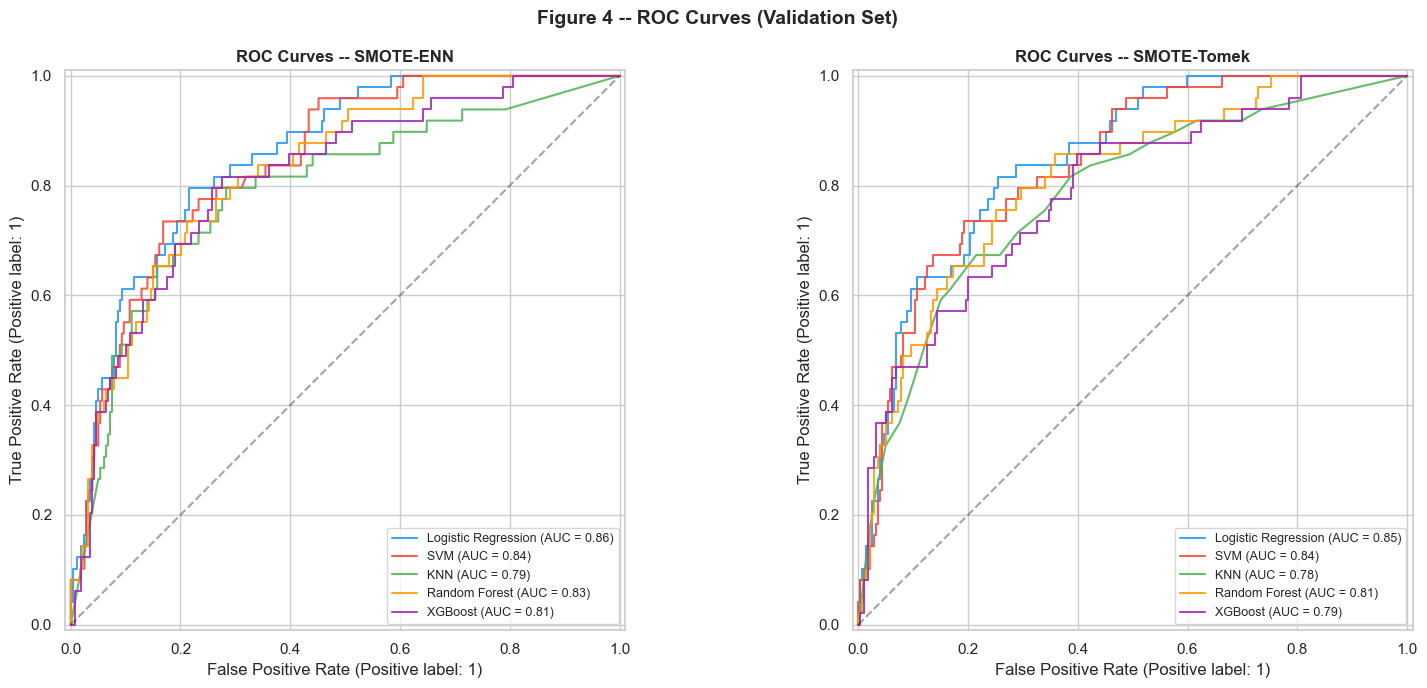

Saved fig4_roc_curves.png


In [ ]:
# ── 10b. ROC curves — all models, both strategies ──
# Define once here; reused by all subsequent visualisation cells
strategy_pipelines_list = [
    ("SMOTE-ENN", smoteenn_pipelines),
    ("SMOTE-Tomek", smotetomek_pipelines),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (strategy_name, pipelines) in zip(axes, strategy_pipelines_list):
    for i, (model_name, pipe) in enumerate(pipelines.items()):
        RocCurveDisplay.from_estimator(
            pipe,
            X_val,
            y_val,
            ax=ax,
            name=model_name,
            color=PALETTE[i % len(PALETTE)],
            alpha=0.85,
        )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title("ROC Curves -- " + strategy_name, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Figure 4 -- ROC Curves (Validation Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig4_roc_curves.png")

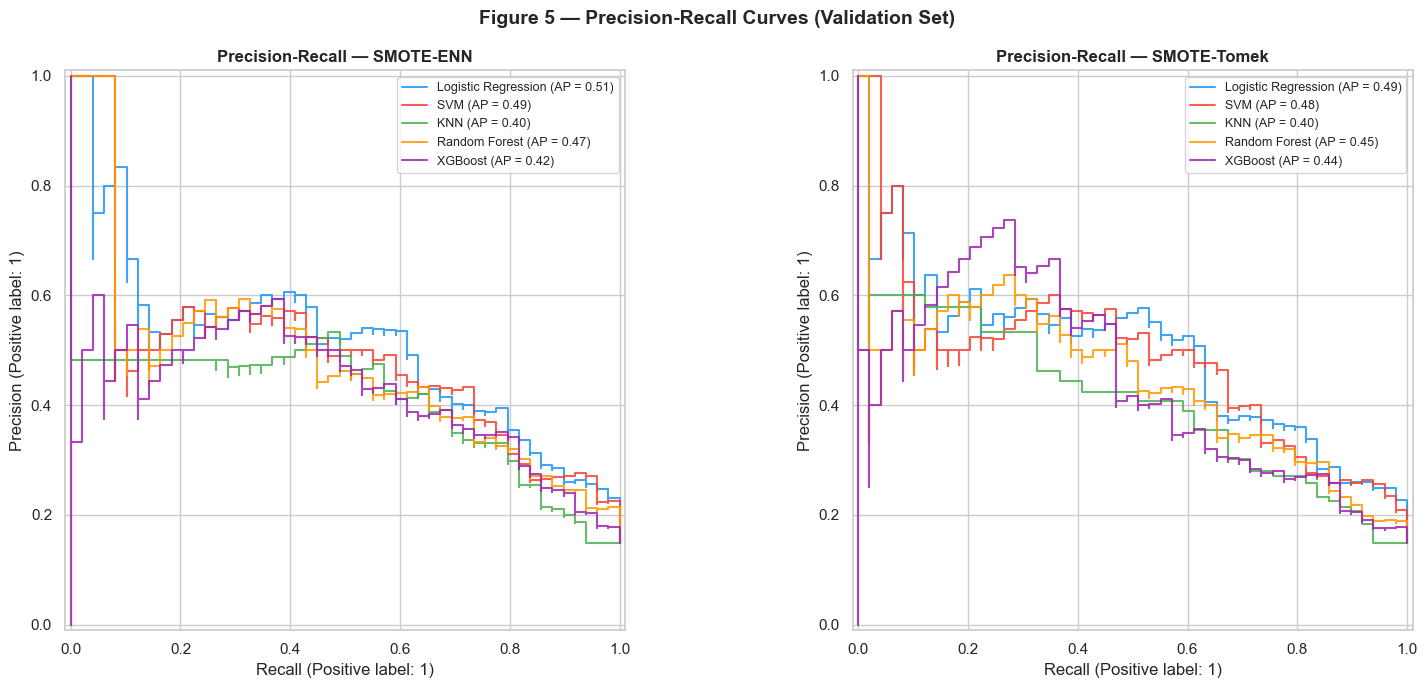

In [ ]:
# ── 10c. Precision-Recall curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (strategy_name, pipelines) in zip(axes, strategy_pipelines_list):
    for i, (model_name, pipe) in enumerate(pipelines.items()):
        PrecisionRecallDisplay.from_estimator(
            pipe,
            X_val,
            y_val,
            ax=ax,
            name=model_name,
            color=PALETTE[i % len(PALETTE)],
            alpha=0.85,
        )
    ax.set_title(f"Precision-Recall — {strategy_name}", fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle(
    "Figure 5 — Precision-Recall Curves (Validation Set)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig5_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

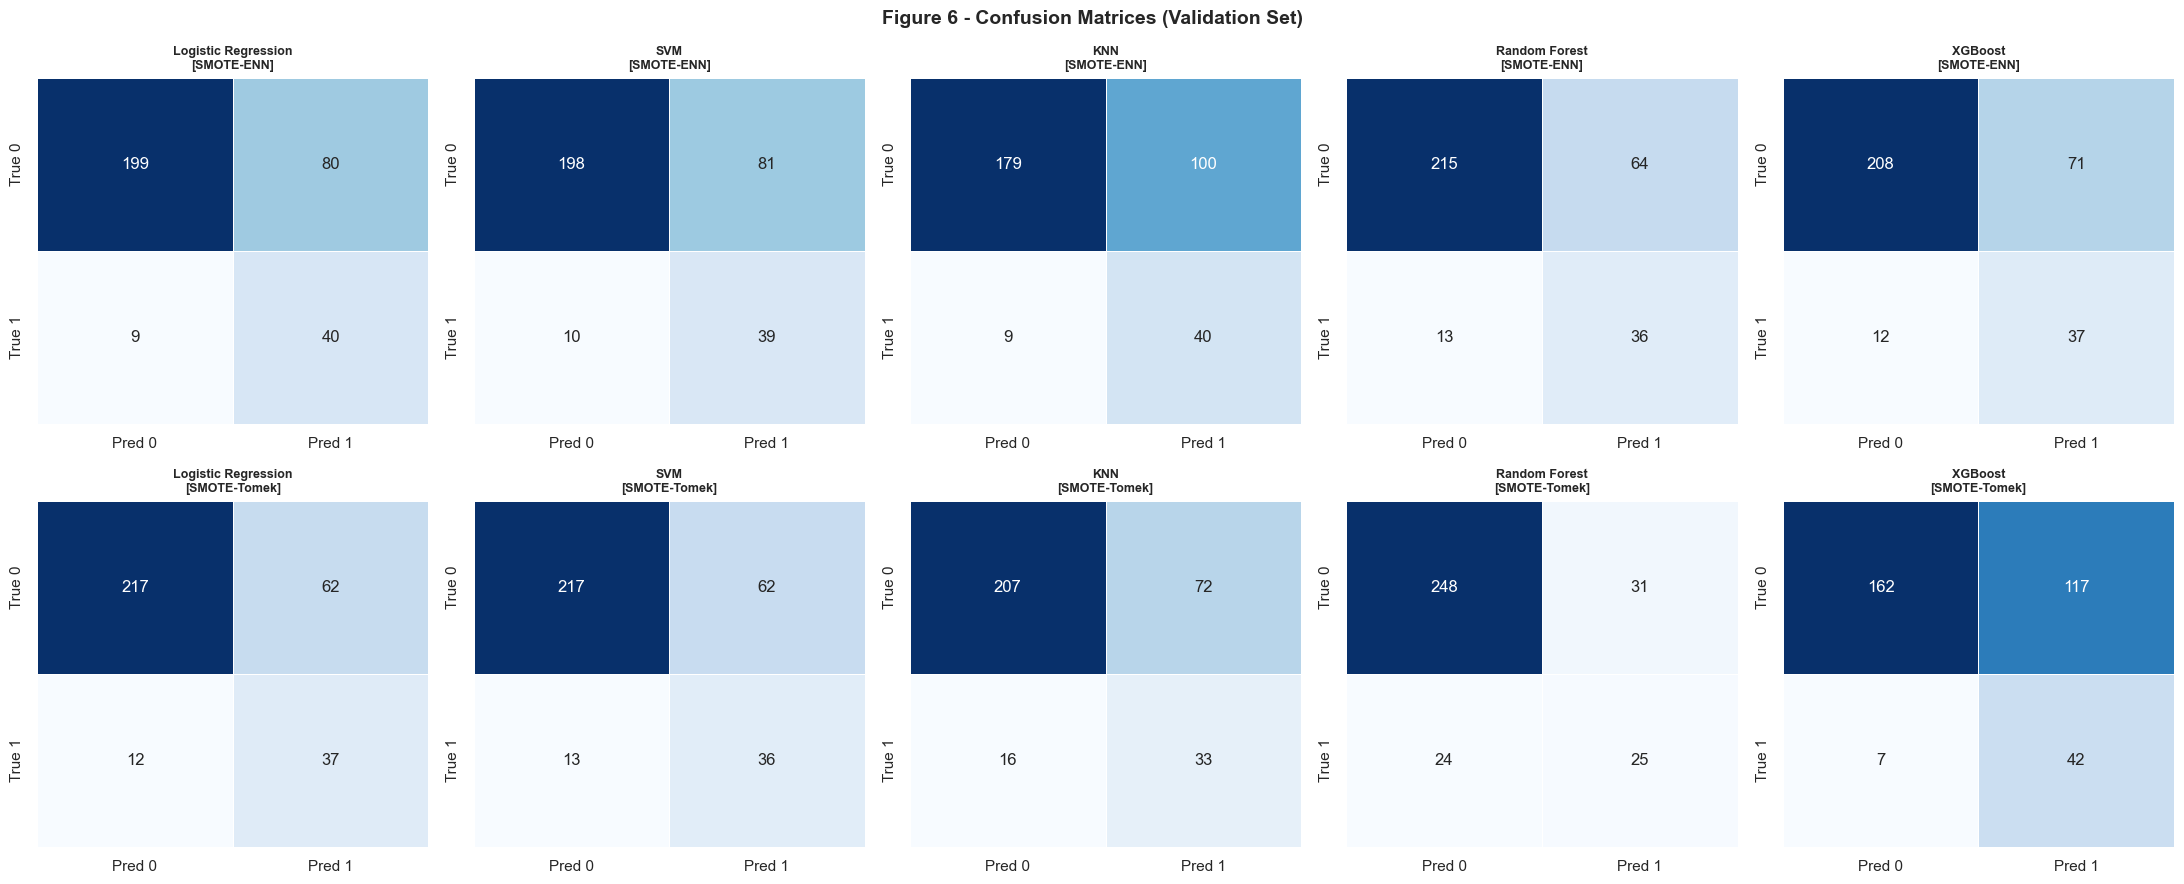

Saved fig6_confusion_matrices.png


In [ ]:
# ── 10d. Confusion matrices grid ──
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for row_idx, (strategy_name, pipelines) in enumerate(strategy_pipelines_list):
    for col_idx, (model_name, pipe) in enumerate(pipelines.items()):
        ax = axes[row_idx, col_idx]
        y_pred = pipe.predict(X_val)
        cm = confusion_matrix(y_val, y_pred)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax,
            linewidths=0.5,
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
        )
        title = model_name + chr(10) + "[" + strategy_name + "]"
        ax.set_title(title, fontsize=9, fontweight="bold")

plt.suptitle(
    "Figure 6 - Confusion Matrices (Validation Set)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig6_confusion_matrices.png")

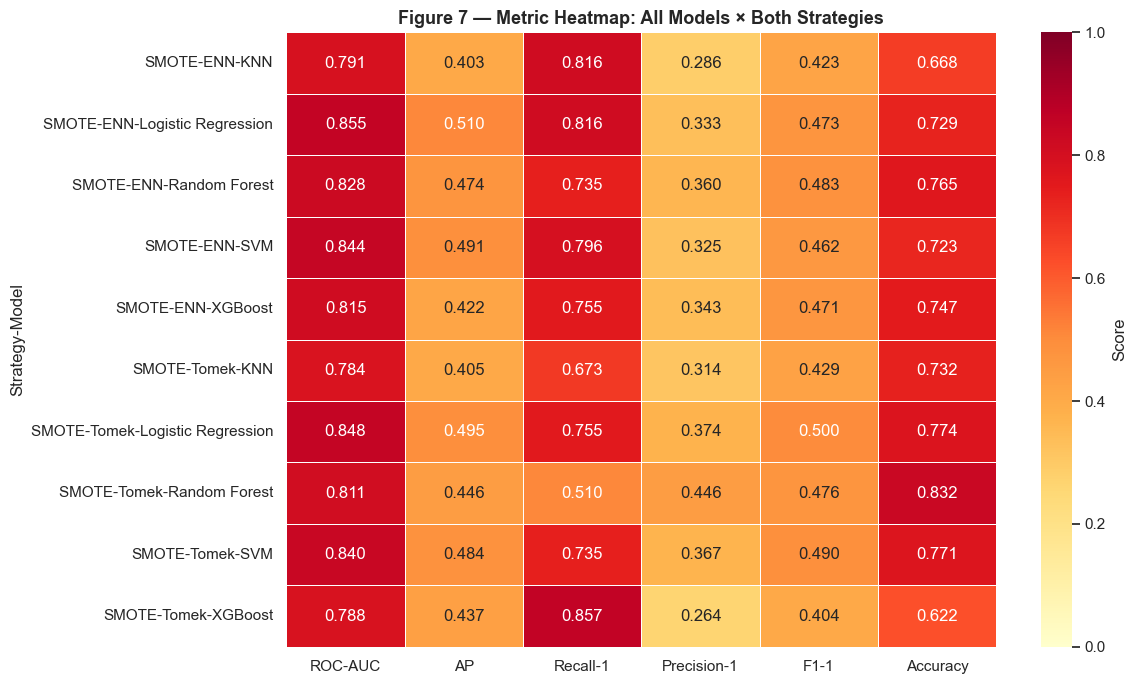

In [ ]:
# ── 10e. Heatmap: all metrics across models & strategies ──
heat_df = all_results.set_index(["Strategy", "Model"])[
    ["ROC-AUC", "AP", "Recall-1", "Precision-1", "F1-1", "Accuracy"]
]
heat_df = heat_df.sort_index()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heat_df.astype(float),
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Score"},
)
ax.set_title(
    "Figure 7 — Metric Heatmap: All Models × Both Strategies",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig7_metric_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## GROUP 11 — Final Test Set Evaluation (Hold-out)


In [ ]:
# ── Evaluate ALL pipelines on the held-out test set ──
test_results = []

for strategy_name, pipelines in strategy_pipelines_list:
    for model_name, pipe in pipelines.items():
        metrics = evaluate_pipeline(pipe, X_test, y_test, model_name, strategy_name)
        test_results.append(metrics)

test_df = pd.DataFrame(test_results)
display_cols = [
    "Model",
    "Strategy",
    "ROC-AUC",
    "AP",
    "Recall-1",
    "Precision-1",
    "F1-1",
    "Accuracy",
]

print("=" * 90)
print(" TEST SET RESULTS — Final Hold-out Evaluation")
print("=" * 90)
print(
    test_df[display_cols]
    .sort_values(["ROC-AUC", "Recall-1"], ascending=False)
    .to_string(index=False)
)

 TEST SET RESULTS — Final Hold-out Evaluation
              Model    Strategy  ROC-AUC     AP  Recall-1  Precision-1   F1-1  Accuracy
Logistic Regression   SMOTE-ENN   0.8016 0.3624    0.7347       0.3158 0.4417    0.7226
Logistic Regression SMOTE-Tomek   0.8016 0.3706    0.5918       0.3333 0.4265    0.7622
      Random Forest SMOTE-Tomek   0.7995 0.3581    0.5102       0.4630 0.4854    0.8384
                SVM SMOTE-Tomek   0.7974 0.3752    0.6735       0.3474 0.4583    0.7622
                SVM   SMOTE-ENN   0.7951 0.3691    0.7143       0.3211 0.4430    0.7317
      Random Forest   SMOTE-ENN   0.7896 0.3492    0.6531       0.3516 0.4571    0.7683
            XGBoost SMOTE-Tomek   0.7653 0.3405    0.8163       0.2367 0.3670    0.5793
            XGBoost   SMOTE-ENN   0.7645 0.3434    0.6735       0.3113 0.4258    0.7287
                KNN   SMOTE-ENN   0.7427 0.3170    0.7551       0.2662 0.3936    0.6524
                KNN SMOTE-Tomek   0.7304 0.3194    0.5714       0.2772 0.3

In [ ]:
# ── Pivot: Validation vs Test gap ──
print("")
print("Validation vs Test ROC-AUC Gap (overfitting check)")
print("")
for strategy_name in ["SMOTE-ENN", "SMOTE-Tomek"]:
    val_sub = all_results[all_results["Strategy"] == strategy_name].set_index("Model")[
        "ROC-AUC"
    ]
    test_sub = test_df[test_df["Strategy"] == strategy_name].set_index("Model")[
        "ROC-AUC"
    ]
    gap_df = pd.DataFrame({"Val AUC": val_sub, "Test AUC": test_sub})
    gap_df["Gap"] = gap_df["Val AUC"] - gap_df["Test AUC"]
    print("  Strategy: " + strategy_name)
    print(gap_df.round(4).to_string())
    print("")


Validation vs Test ROC-AUC Gap (overfitting check)

  Strategy: SMOTE-ENN
                     Val AUC  Test AUC    Gap
Model                                        
Logistic Regression   0.8551    0.8016 0.0535
SVM                   0.8443    0.7951 0.0492
KNN                   0.7912    0.7427 0.0485
Random Forest         0.8275    0.7896 0.0379
XGBoost               0.8146    0.7645 0.0501

  Strategy: SMOTE-Tomek
                     Val AUC  Test AUC    Gap
Model                                        
Logistic Regression   0.8484    0.8016 0.0468
SVM                   0.8397    0.7974 0.0423
KNN                   0.7844    0.7304 0.0540
Random Forest         0.8107    0.7995 0.0112
XGBoost               0.7885    0.7653 0.0232



In [ ]:
# ── Best overall model on test ──
best_test_row = test_df.sort_values(["Recall-1", "ROC-AUC"], ascending=False).iloc[0]
print("Best model on TEST (by Recall then AUC):")
print("   Model:     " + best_test_row["Model"])
print("   Strategy:  " + best_test_row["Strategy"])
print("   ROC-AUC:   " + str(best_test_row["ROC-AUC"]))
print("   Recall-1:  " + str(best_test_row["Recall-1"]))
print("   Precision: " + str(best_test_row["Precision-1"]))
print("   F1-1:      " + str(best_test_row["F1-1"]))

# Save best pipeline
if best_test_row["Strategy"] == "SMOTE-ENN":
    best_final_pipe = smoteenn_pipelines[best_test_row["Model"]]
else:
    best_final_pipe = smotetomek_pipelines[best_test_row["Model"]]

joblib.dump(best_final_pipe, "cvd_best_model.pkl")
print("")
print("Best model saved to cvd_best_model.pkl")

Best model on TEST (by Recall then AUC):
   Model:     XGBoost
   Strategy:  SMOTE-Tomek
   ROC-AUC:   0.7653
   Recall-1:  0.8163
   Precision: 0.2367
   F1-1:      0.367

Best model saved to cvd_best_model.pkl


## GROUP 12 — Detailed Classification Reports (Best Models)


In [ ]:
# ── Print classification report for best model from each strategy ──
for strategy_name, pipelines in strategy_pipelines_list:
    best_row = (
        test_df[test_df["Strategy"] == strategy_name]
        .sort_values("ROC-AUC", ascending=False)
        .iloc[0]
    )
    best_model_name = best_row["Model"]
    pipe = pipelines[best_model_name]

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(f"{'='*60}")
    print(f" {strategy_name} — Best: {best_model_name}")
    print(f"{'='*60}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(
        classification_report(
            y_test, y_pred, target_names=["No CVD (0)", "CVD (1)"], digits=4
        )
    )

 SMOTE-ENN — Best: Logistic Regression
ROC-AUC: 0.8016
[[201  78]
 [ 13  36]]
              precision    recall  f1-score   support

  No CVD (0)     0.9393    0.7204    0.8154       279
     CVD (1)     0.3158    0.7347    0.4417        49

    accuracy                         0.7226       328
   macro avg     0.6275    0.7276    0.6286       328
weighted avg     0.8461    0.7226    0.7596       328

 SMOTE-Tomek — Best: Logistic Regression
ROC-AUC: 0.8016
[[221  58]
 [ 20  29]]
              precision    recall  f1-score   support

  No CVD (0)     0.9170    0.7921    0.8500       279
     CVD (1)     0.3333    0.5918    0.4265        49

    accuracy                         0.7622       328
   macro avg     0.6252    0.6920    0.6382       328
weighted avg     0.8298    0.7622    0.7867       328



## GROUP 13 — Threshold Tuning (Maximise F1 & Target Recall)


In [ ]:
# ── 13a. Find optimal threshold per model & strategy ──
# For each model we scan thresholds 0.05–0.95 and record:
#   (i)  threshold that maximises F1 for the positive class
#   (ii) threshold that achieves >= TARGET_RECALL with highest precision

TARGET_RECALL = 0.80  # clinically motivated: catch at least 80% of CVD cases

tuning_records = []

for strategy_name, pipelines in strategy_pipelines_list:
    for model_name, pipe in pipelines.items():
        y_prob = pipe.predict_proba(X_val)[:, 1]

        thresholds = np.arange(0.05, 0.96, 0.01)
        best_f1, best_f1_thresh = -1, 0.5
        best_recall_thresh, best_recall_prec = 0.5, 0.0

        for t in thresholds:
            y_pred_t = (y_prob >= t).astype(int)
            f1 = f1_score(y_val, y_pred_t, zero_division=0)
            rec = recall_score(y_val, y_pred_t, zero_division=0)
            pre = precision_score(y_val, y_pred_t, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_f1_thresh = t

            # Best precision among thresholds that hit target recall
            if rec >= TARGET_RECALL and pre > best_recall_prec:
                best_recall_prec = pre
                best_recall_thresh = t

        # Metrics at best-F1 threshold
        y_pred_f1 = (y_prob >= best_f1_thresh).astype(int)
        # Metrics at target-recall threshold
        y_pred_tr = (y_prob >= best_recall_thresh).astype(int)

        tuning_records.append(
            {
                "Model": model_name,
                "Strategy": strategy_name,
                # ── best-F1 threshold ──
                "F1-Thresh": round(best_f1_thresh, 2),
                "F1@thresh": round(f1_score(y_val, y_pred_f1, zero_division=0), 4),
                "Recall@F1-thresh": round(
                    recall_score(y_val, y_pred_f1, zero_division=0), 4
                ),
                "Prec@F1-thresh": round(
                    precision_score(y_val, y_pred_f1, zero_division=0), 4
                ),
                # ── target-recall threshold ──
                "Recall-Thresh": round(best_recall_thresh, 2),
                "Recall@80": round(recall_score(y_val, y_pred_tr, zero_division=0), 4),
                "Prec@80": round(precision_score(y_val, y_pred_tr, zero_division=0), 4),
                "F1@80": round(f1_score(y_val, y_pred_tr, zero_division=0), 4),
                # store probs for later
                "_y_prob": y_prob,
            }
        )

tuning_df = pd.DataFrame(tuning_records)

print("=" * 95)
print(" THRESHOLD TUNING RESULTS (Validation Set)")
print("=" * 95)
display_cols = [
    "Model",
    "Strategy",
    "F1-Thresh",
    "Recall@F1-thresh",
    "Prec@F1-thresh",
    "F1@thresh",
    "Recall-Thresh",
    "Recall@80",
    "Prec@80",
    "F1@80",
]
print(tuning_df[display_cols].to_string(index=False))

 THRESHOLD TUNING RESULTS (Validation Set)
              Model    Strategy  F1-Thresh  Recall@F1-thresh  Prec@F1-thresh  F1@thresh  Recall-Thresh  Recall@80  Prec@80  F1@80
Logistic Regression   SMOTE-ENN     0.7600            0.6122          0.5172     0.5607         0.5200     0.8163   0.3540 0.4938
                SVM   SMOTE-ENN     0.8000            0.7347          0.4337     0.5455         0.4800     0.8163   0.3030 0.4420
                KNN   SMOTE-ENN     0.8000            0.6531          0.4211     0.5120         0.5300     0.8163   0.2985 0.4372
      Random Forest   SMOTE-ENN     0.6100            0.6531          0.4267     0.5161         0.3800     0.8163   0.3150 0.4545
            XGBoost   SMOTE-ENN     0.7700            0.6939          0.3908     0.5000         0.3700     0.8163   0.3361 0.4762
Logistic Regression SMOTE-Tomek     0.6500            0.6122          0.5263     0.5660         0.4600     0.8163   0.3571 0.4969
                SVM SMOTE-Tomek     0.6600     

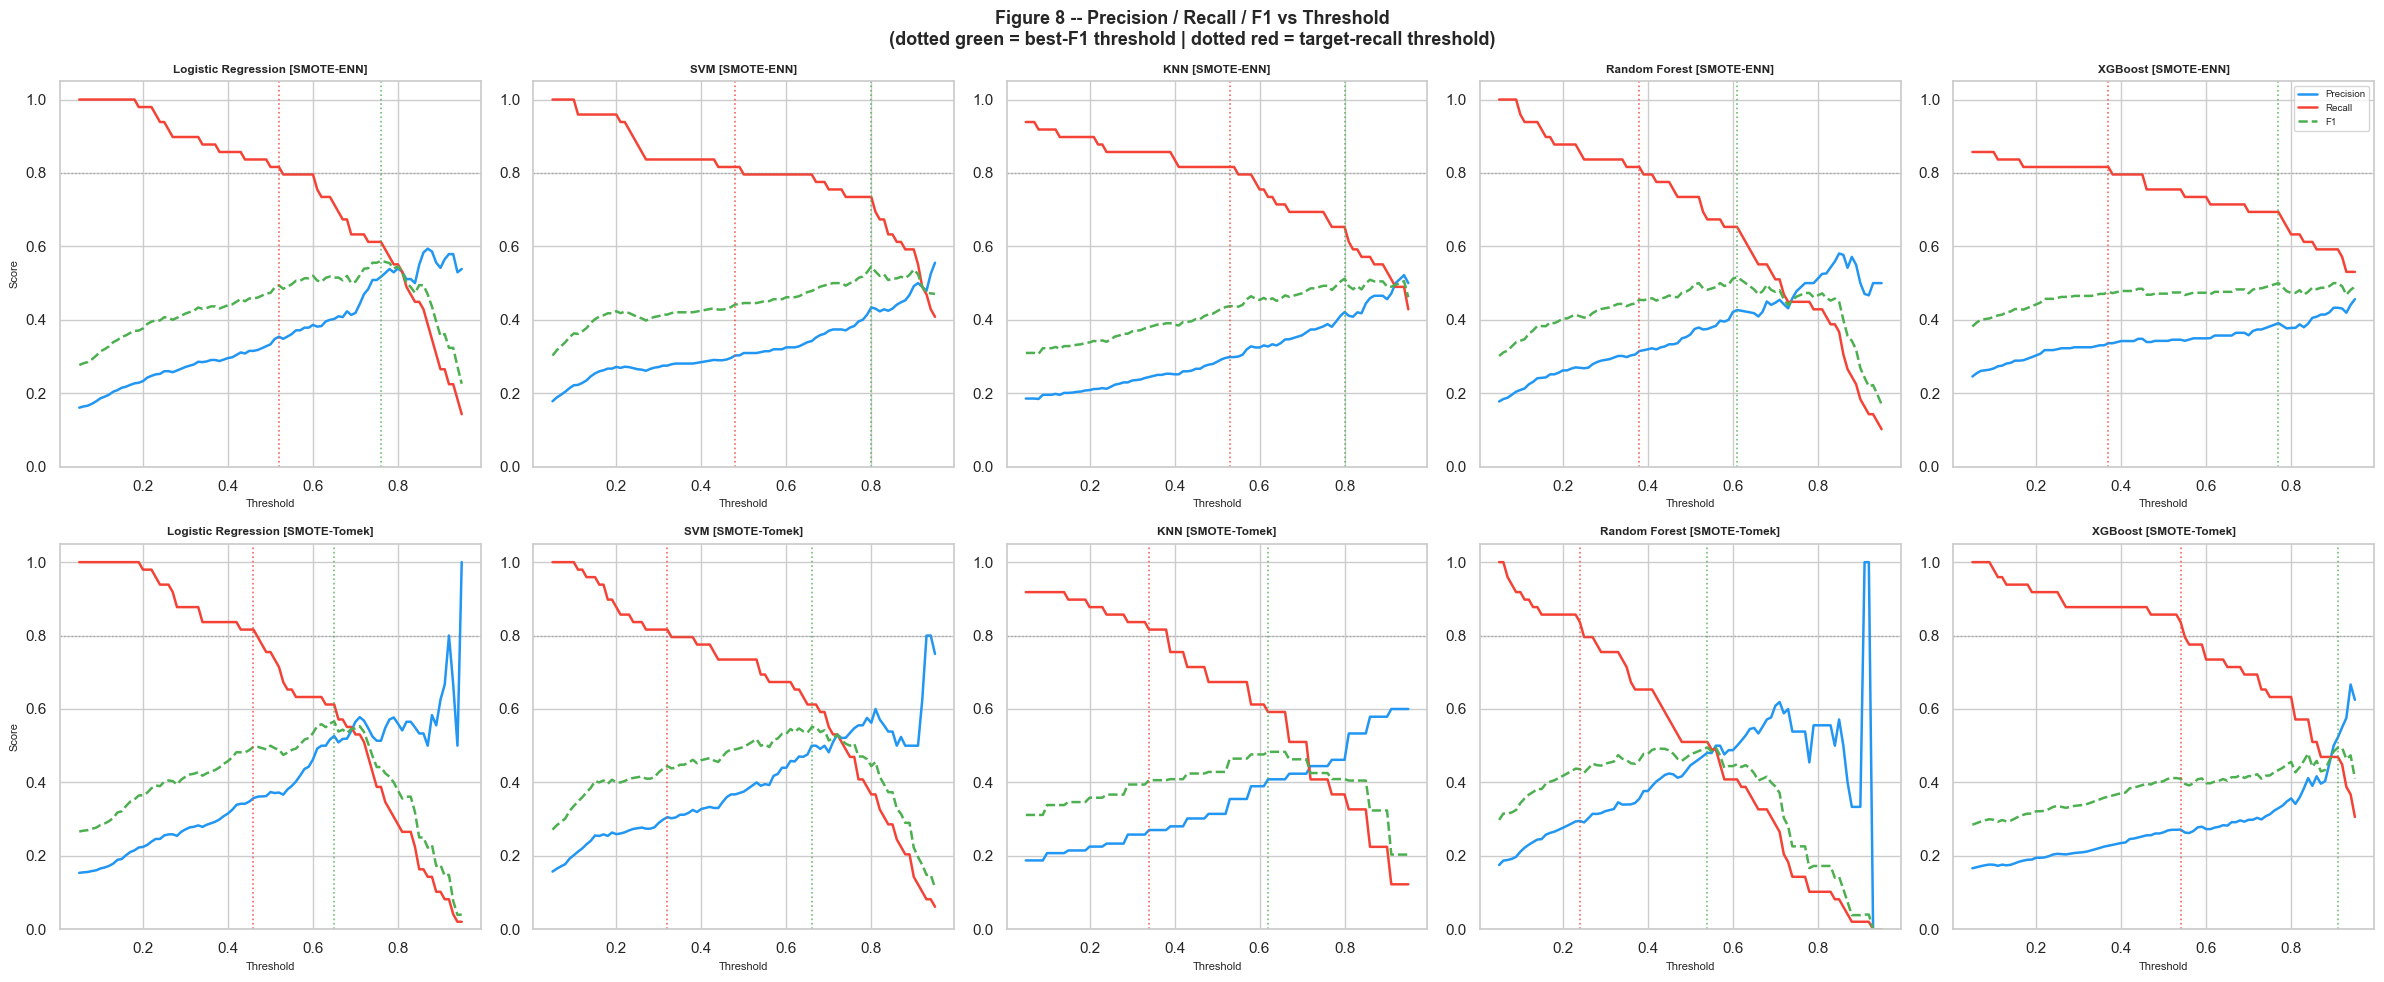

Saved fig8_threshold_curves.png


In [ ]:
# ── 13b. Precision-Recall vs Threshold curves — all models, both strategies ──
fig, axes = plt.subplots(2, 5, figsize=(24, 10))

for row_idx, (strategy_name, pipelines) in enumerate(strategy_pipelines_list):
    for col_idx, (model_name, pipe) in enumerate(pipelines.items()):

        ax = axes[row_idx, col_idx]

        # Retrieve stored probs
        rec = tuning_df[
            (tuning_df["Model"] == model_name)
            & (tuning_df["Strategy"] == strategy_name)
        ].iloc[0]

        y_prob = rec["_y_prob"]
        thresholds = np.arange(0.05, 0.96, 0.01)

        precisions, recalls, f1s = [], [], []
        for t in thresholds:
            y_p = (y_prob >= t).astype(int)
            precisions.append(precision_score(y_val, y_p, zero_division=0))
            recalls.append(recall_score(y_val, y_p, zero_division=0))
            f1s.append(f1_score(y_val, y_p, zero_division=0))

        ax.plot(thresholds, precisions, color=PALETTE[0], label="Precision", lw=1.8)
        ax.plot(thresholds, recalls, color=PALETTE[1], label="Recall", lw=1.8)
        ax.plot(thresholds, f1s, color=PALETTE[2], label="F1", lw=1.8, linestyle="--")

        # Mark best-F1 threshold
        ax.axvline(rec["F1-Thresh"], color=PALETTE[2], linestyle=":", alpha=0.8, lw=1.2)
        ax.axvline(
            rec["Recall-Thresh"], color=PALETTE[1], linestyle=":", alpha=0.8, lw=1.2
        )
        ax.axhline(TARGET_RECALL, color="grey", linestyle=":", alpha=0.5, lw=1)

        ax.set_title(
            model_name + " [" + strategy_name + "]", fontsize=8.5, fontweight="bold"
        )
        ax.set_xlabel("Threshold", fontsize=8)
        ax.set_ylim(0, 1.05)
        if col_idx == 0:
            ax.set_ylabel("Score", fontsize=8)
        if row_idx == 0 and col_idx == 4:
            ax.legend(fontsize=7, loc="upper right")

plt.suptitle(
    "Figure 8 -- Precision / Recall / F1 vs Threshold\n"
    "(dotted green = best-F1 threshold | dotted red = target-recall threshold)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig8_threshold_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig8_threshold_curves.png")

In [ ]:
# ── 13c. Re-evaluate all models on TEST set at both tuned thresholds ──
tuned_test_records = []

for strategy_name, pipelines in strategy_pipelines_list:
    for model_name, pipe in pipelines.items():

        # Get tuning info from validation
        t_row = tuning_df[
            (tuning_df["Model"] == model_name)
            & (tuning_df["Strategy"] == strategy_name)
        ].iloc[0]

        y_prob_test = pipe.predict_proba(X_test)[:, 1]

        for thresh_label, thresh_val in [
            ("Default (0.50)", 0.50),
            ("Best-F1", t_row["F1-Thresh"]),
            ("Target-Recall", t_row["Recall-Thresh"]),
        ]:
            y_pred_t = (y_prob_test >= thresh_val).astype(int)
            tuned_test_records.append(
                {
                    "Model": model_name,
                    "Strategy": strategy_name,
                    "Threshold": thresh_label,
                    "Thresh-Val": round(thresh_val, 2),
                    "ROC-AUC": round(roc_auc_score(y_test, y_prob_test), 4),
                    "Recall-1": round(
                        recall_score(y_test, y_pred_t, zero_division=0), 4
                    ),
                    "Precision-1": round(
                        precision_score(y_test, y_pred_t, zero_division=0), 4
                    ),
                    "F1-1": round(f1_score(y_test, y_pred_t, zero_division=0), 4),
                    "Accuracy": round((y_pred_t == y_test).mean(), 4),
                }
            )

tuned_test_df = pd.DataFrame(tuned_test_records)

print("=" * 100)
print(" TEST SET -- ALL MODELS x BOTH STRATEGIES x ALL THRESHOLDS")
print("=" * 100)
cols = [
    "Model",
    "Strategy",
    "Threshold",
    "Thresh-Val",
    "ROC-AUC",
    "Recall-1",
    "Precision-1",
    "F1-1",
    "Accuracy",
]
print(
    tuned_test_df[cols]
    .sort_values(["Strategy", "Model", "Thresh-Val"])
    .to_string(index=False)
)

 TEST SET -- ALL MODELS x BOTH STRATEGIES x ALL THRESHOLDS
              Model    Strategy      Threshold  Thresh-Val  ROC-AUC  Recall-1  Precision-1   F1-1  Accuracy
                KNN   SMOTE-ENN Default (0.50)      0.5000   0.7427    0.7551       0.2662 0.3936    0.6524
                KNN   SMOTE-ENN  Target-Recall      0.5300   0.7427    0.7143       0.2672 0.3889    0.6646
                KNN   SMOTE-ENN        Best-F1      0.8000   0.7427    0.4898       0.3380 0.4000    0.7805
Logistic Regression   SMOTE-ENN Default (0.50)      0.5000   0.8016    0.7347       0.3158 0.4417    0.7226
Logistic Regression   SMOTE-ENN  Target-Recall      0.5200   0.8016    0.7143       0.3125 0.4348    0.7226
Logistic Regression   SMOTE-ENN        Best-F1      0.7600   0.8016    0.5102       0.4237 0.4630    0.8232
      Random Forest   SMOTE-ENN  Target-Recall      0.3800   0.7896    0.7551       0.3109 0.4405    0.7134
      Random Forest   SMOTE-ENN Default (0.50)      0.5000   0.7896    0.6531

In [ ]:
# ── 13d. Summary: Default vs Tuned — gain in Recall & F1 ──
print("")
print("=" * 80)
print(" GAIN FROM THRESHOLD TUNING  (Test Set, Best-F1 threshold vs Default 0.50)")
print("=" * 80)

default_df = tuned_test_df[tuned_test_df["Threshold"] == "Default (0.50)"].set_index(
    ["Strategy", "Model"]
)
bestf1_df = tuned_test_df[tuned_test_df["Threshold"] == "Best-F1"].set_index(
    ["Strategy", "Model"]
)

gain_records = []
for idx in default_df.index:
    d = default_df.loc[idx]
    b = bestf1_df.loc[idx]
    gain_records.append(
        {
            "Strategy": idx[0],
            "Model": idx[1],
            "Thresh (tuned)": b["Thresh-Val"],
            "Recall (def)": d["Recall-1"],
            "Recall (tuned)": b["Recall-1"],
            "Recall gain": round(b["Recall-1"] - d["Recall-1"], 4),
            "F1 (def)": d["F1-1"],
            "F1 (tuned)": b["F1-1"],
            "F1 gain": round(b["F1-1"] - d["F1-1"], 4),
        }
    )

gain_df = pd.DataFrame(gain_records)
print(gain_df.to_string(index=False))

print("")
print("Best overall on TEST after threshold tuning (by Recall-1):")
best = (
    tuned_test_df[tuned_test_df["Threshold"] != "Default (0.50)"]
    .sort_values(["Recall-1", "F1-1"], ascending=False)
    .iloc[0]
)
print("  Model:      " + best["Model"])
print("  Strategy:   " + best["Strategy"])
print("  Threshold:  " + best["Threshold"] + " (" + str(best["Thresh-Val"]) + ")")
print("  ROC-AUC:    " + str(best["ROC-AUC"]))
print("  Recall-1:   " + str(best["Recall-1"]))
print("  Precision:  " + str(best["Precision-1"]))
print("  F1-1:       " + str(best["F1-1"]))


 GAIN FROM THRESHOLD TUNING  (Test Set, Best-F1 threshold vs Default 0.50)
   Strategy               Model  Thresh (tuned)  Recall (def)  Recall (tuned)  Recall gain  F1 (def)  F1 (tuned)  F1 gain
  SMOTE-ENN Logistic Regression          0.7600        0.7347          0.5102      -0.2245    0.4417      0.4630   0.0213
  SMOTE-ENN                 SVM          0.8000        0.7551          0.5510      -0.2041    0.4277      0.4091  -0.0186
  SMOTE-ENN                 KNN          0.8000        0.7551          0.4898      -0.2653    0.3936      0.4000   0.0064
  SMOTE-ENN       Random Forest          0.6100        0.6531          0.5918      -0.0613    0.4571      0.4531  -0.0040
  SMOTE-ENN             XGBoost          0.7700        0.6735          0.5714      -0.1021    0.4258      0.4148  -0.0110
SMOTE-Tomek Logistic Regression          0.6500        0.5918          0.5102      -0.0816    0.4265      0.4902   0.0637
SMOTE-Tomek                 SVM          0.6600        0.6735         

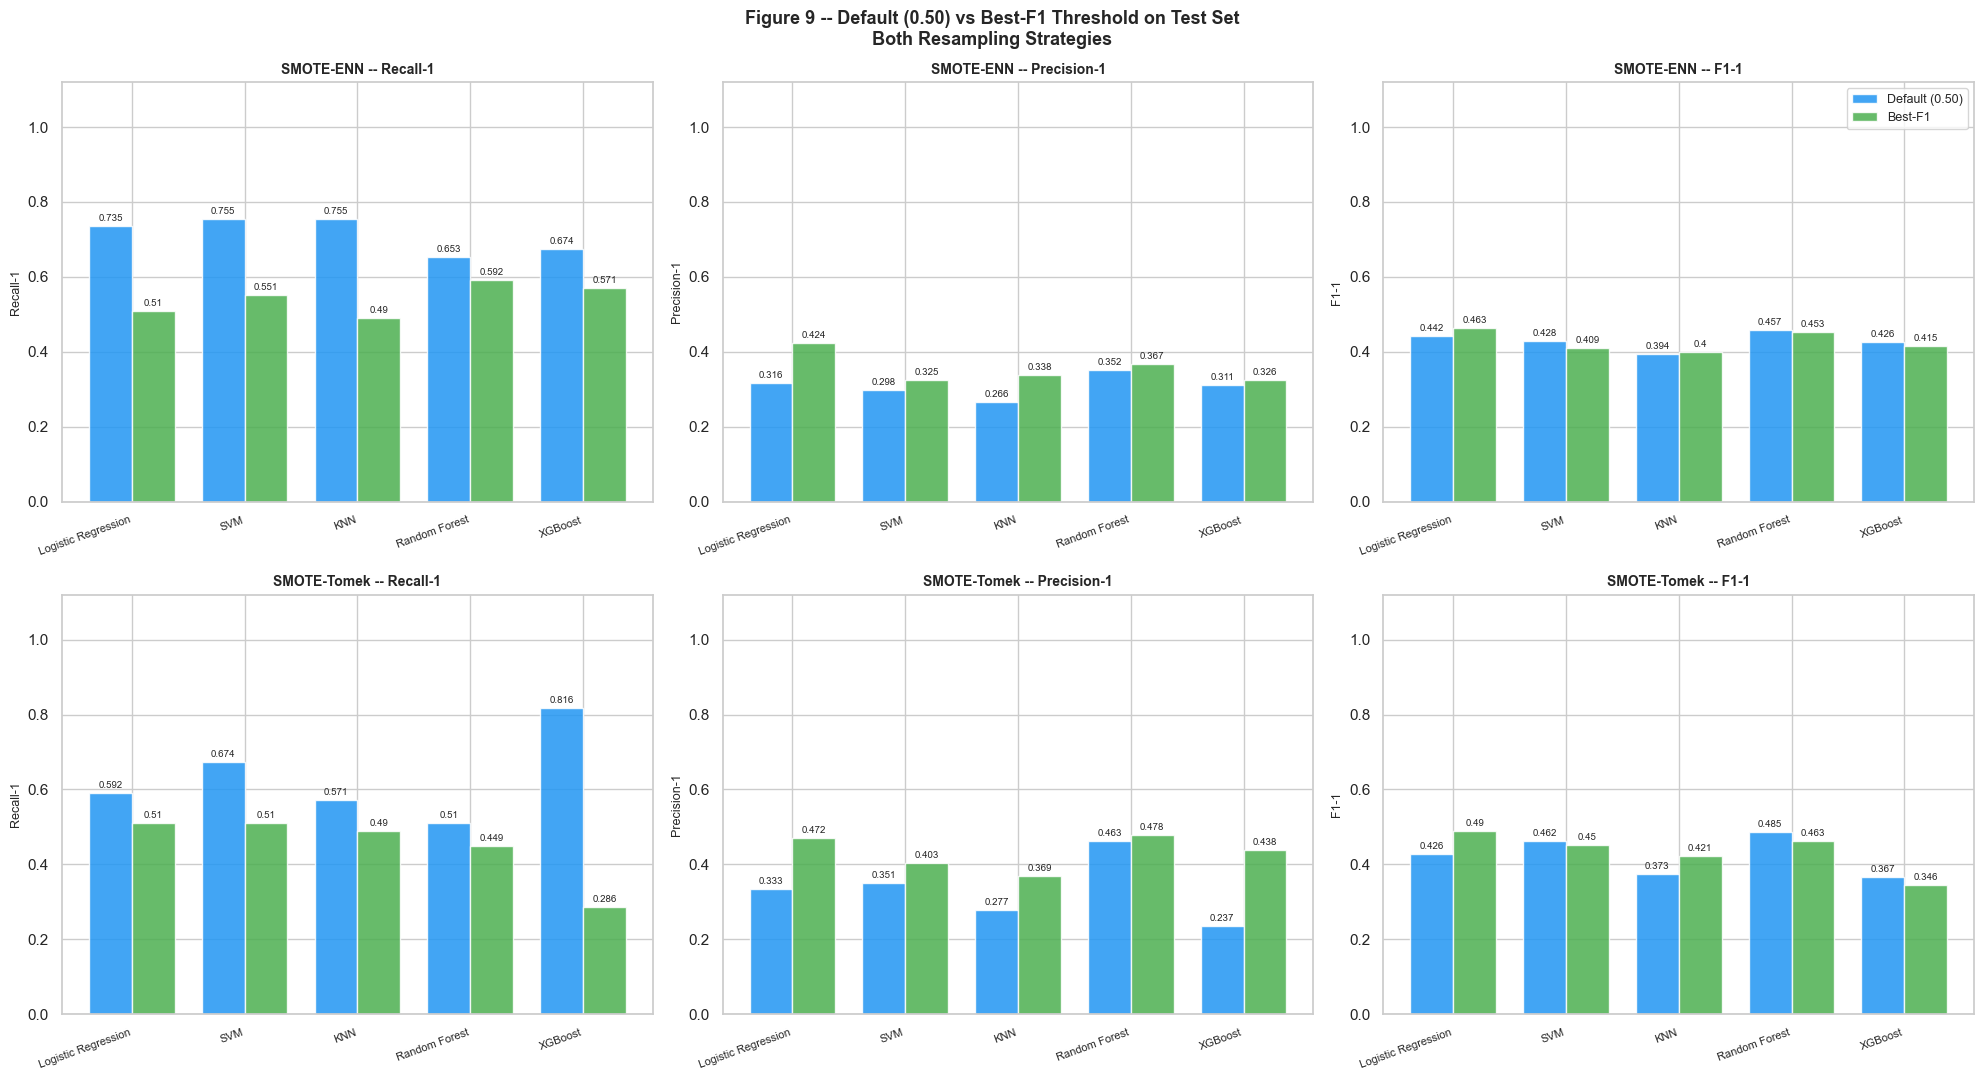

Saved fig9_threshold_comparison.png


In [ ]:
# ── 13e. Visual comparison: Default vs Best-F1 threshold — bar chart ──
strategies = ["SMOTE-ENN", "SMOTE-Tomek"]
model_names = list(base_models.keys())
metrics_show = ["Recall-1", "Precision-1", "F1-1"]
thresh_labels = ["Default (0.50)", "Best-F1"]
bar_colors = {
    "Default (0.50)": PALETTE[0],
    "Best-F1": PALETTE[2],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for row_idx, strategy in enumerate(strategies):
    for col_idx, metric in enumerate(metrics_show):
        ax = axes[row_idx, col_idx]
        x = np.arange(len(model_names))
        width = 0.38

        for j, thresh_label in enumerate(thresh_labels):
            subset = tuned_test_df[
                (tuned_test_df["Strategy"] == strategy)
                & (tuned_test_df["Threshold"] == thresh_label)
            ].set_index("Model")
            vals = [subset.loc[m, metric] for m in model_names]
            bars = ax.bar(
                x + (j - 0.5) * width,
                vals,
                width,
                label=thresh_label,
                color=bar_colors[thresh_label],
                alpha=0.85,
                edgecolor="white",
            )
            for bar in bars:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    str(round(bar.get_height(), 3)),
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

        ax.set_title(strategy + " -- " + metric, fontweight="bold", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=8)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel(metric, fontsize=9)
        if row_idx == 0 and col_idx == 2:
            ax.legend(fontsize=9)

plt.suptitle(
    "Figure 9 -- Default (0.50) vs Best-F1 Threshold on Test Set\n"
    "Both Resampling Strategies",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig9_threshold_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig9_threshold_comparison.png")

In [ ]:
# ──────────────────────────────────────────────────────────────
# Step 1: No-Resampling Baseline (class_weight only)
# ──────────────────────────────────────────────────────────────

from sklearn.pipeline import Pipeline

# Create clean pipeline with NO resampler
no_resample_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",  # or your best ratio, e.g. {0:1, 1:6}
                max_iter=2000,
                random_state=RANDOM_STATE,
                solver="lbfgs",
            ),
        ),
    ]
)

print("Training No-Resampling Logistic Regression...")
no_resample_pipe.fit(X_train, y_train)

# Evaluate on validation set
print("\nNo-Resampling Baseline (class_weight='balanced') on Validation:")
y_val_pred_nr = no_resample_pipe.predict(X_val)
y_val_prob_nr = no_resample_pipe.predict_proba(X_val)[:, 1]

print(confusion_matrix(y_val, y_val_pred_nr))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_nr, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_nr):.4f}")

# Compare to your current best (SMOTE-ENN or SMOTE-Tomek) model
# Replace 'best_pipe' with the name of your current best pipeline variable
print("\nCurrent best model (with resampling) for reference:")
y_val_pred_best = best_final_pipe.predict(
    X_val
)  # ← change 'best_pipe' to your variable
y_val_prob_best = best_final_pipe.predict_proba(X_val)[:, 1]
print(classification_report(y_val, y_val_pred_best, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_best):.4f}")

Training No-Resampling Logistic Regression...

No-Resampling Baseline (class_weight='balanced') on Validation:
[[215  64]
 [ 12  37]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9471    0.7706    0.8498       279
           1     0.3663    0.7551    0.4933        49

    accuracy                         0.7683       328
   macro avg     0.6567    0.7629    0.6716       328
weighted avg     0.8604    0.7683    0.7965       328

ROC-AUC: 0.8457

Current best model (with resampling) for reference:
              precision    recall  f1-score   support

           0     0.9586    0.5806    0.7232       279
           1     0.2642    0.8571    0.4038        49

    accuracy                         0.6220       328
   macro avg     0.6114    0.7189    0.5635       328
weighted avg     0.8548    0.6220    0.6755       328

ROC-AUC: 0.7885


Feature Selection


In [41]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Fit the current no-resampling pipeline to get transformed features
no_resample_pipe.fit(X_train, y_train)
X_train_transformed = no_resample_pipe.named_steps["preprocessor"].transform(X_train)

# 1. SelectKBest (univariate, fast)
selector_kbest = SelectKBest(score_func=f_classif, k=10)  # try 8, 10, 12
X_train_kbest = selector_kbest.fit_transform(X_train_transformed, y_train)

selected_features_kbest = selector_kbest.get_support()
feature_names = no_resample_pipe.named_steps["preprocessor"].get_feature_names_out()
selected_names_kbest = feature_names[selected_features_kbest]

print("Top 10 features by SelectKBest (f_classif):")
print(selected_names_kbest)

# 2. RFE (recursive, uses the model itself)
rfe_selector = RFE(
    estimator=LogisticRegression(class_weight="balanced", max_iter=2000),
    n_features_to_select=10,
    step=1,
)
rfe_selector.fit(X_train_transformed, y_train)

selected_names_rfe = feature_names[rfe_selector.support_]

print("\nTop 10 features by RFE:")
print(selected_names_rfe)

Top 10 features by SelectKBest (f_classif):
['num__age' 'num__BMI' 'num__Systolic_BP' 'num__Diastolic_BP'
 'num__Heartrate' 'num__Blood_Glucose' 'num__Total_Cholesterol'
 'num__Triglycerides' 'cat__sex_M' 'cat__Diabetes_status_1.0']

Top 10 features by RFE:
['num__age' 'num__BMI' 'num__Systolic_BP' 'num__Diastolic_BP'
 'num__Total_Cholesterol' 'cat__sex_M' 'cat__Smoking_status_1'
 'cat__Alcohol_intake_1.0' 'cat__Physical_activity_1.0'
 'cat__Diabetes_status_1.0']
